# Phase 1: Data Preprocessing & Exploratory Data Analysis (EDA)

## Independent Study — Higher Education Outcomes (IPEDS 2022)

### Objective
This notebook covers Phase 1 of the analysis pipeline. The goal is to:
- Load and understand the IPEDS 2022 dataset
- Document and handle missing values
- Clean and preprocess the data
- Analyze distributions, outliers, and correlations
- Prepare a clean dataset for Phase 2 (Feature Engineering)
  

## 1. Importing Libraries

We begin by importing all the libraries needed for Phase 1.

- **pandas** — data loading and manipulation
- **numpy** — numerical operations
- **matplotlib & seaborn** — data visualization
- **warnings** — to suppress unnecessary output

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Loading the Data
Load the IPEDS 2022 dataset and rename the long column names
into short readable aliases that we will use throughout the notebook.

In [163]:
df_raw = pd.read_csv("CSV - Sheet1.csv")
print(f"Dataset shape: {df_raw.shape[0]:,} institutions × {df_raw.shape[1]} variables")
df_raw.head()

Dataset shape: 2,716 institutions × 24 variables


,unitid,institution name,year,IC2022_AY.In-state average tuition full-time graduates,"EF2022D_RV.Full-time retention rate, 2022",EF2022D_RV.Student-to-faculty ratio,SFA2122_RV.Percent of full-time first-time undergraduates awarded Pell grants,SFA2122_RV.Average amount of institutional grant aid awarded to full-time first-time undergraduates,SFA2122_RV.Percent of full-time first-time undergraduates awarded student loans,SFA2122_RV.Average amount of federal student loans awarded to full-time first-time undergraduates,...,HD2022.FIPS state code,HD2022.Sector of institution,HD2022.Level of institution,HD2022.Control of institution,HD2022.Degree of urbanization (Urban-centric locale),DRVADM2022_RV.Percent admitted - total,DRVEF2022_RV.Total enrollment,DRVEF2022_RV.Part-time enrollment,DRVF2022_RV.Instruction expenses per FTE (GASB),DRVF2022_RV.Instruction expenses per FTE (FASB)
0,100654,Alabama A & M University,2022,10128.0,59.0,19.0,67.0,7617.0,51.0,5855.0,...,Alabama,"Public, 4-year or above",Four or more years,Public,City: Midsize,68.0,6007.0,745.0,7073.0,NaN
1,100663,University of Alabama at Birmingham,2022,8424.0,82.0,18.0,38.0,9548.0,49.0,5142.0,...,Alabama,"Public, 4-year or above",Four or more years,Public,City: Midsize,87.0,21639.0,6559.0,15256.0,NaN
2,100690,Amridge University,2022,10800.0,NaN,12.0,NaN,NaN,NaN,NaN,...,Alabama,"Private not-for-profit, 4-year or above",Four or more years,Private not-for-profit,City: Midsize,NaN,647.0,387.0,NaN,5927.0
3,100706,University of Alabama in Huntsville,2022,10632.0,80.0,17.0,20.0,8014.0,40.0,5091.0,...,Alabama,"Public, 4-year or above",Four or more years,Public,City: Midsize,78.0,9237.0,2650.0,8747.0,NaN
4,100724,Alabama State University,2022,7416.0,60.0,14.0,78.0,6804.0,83.0,5754.0,...,Alabama,"Public, 4-year or above",Four or more years,Public,City: Midsize,97.0,3828.0,403.0,9349.0,NaN


## 3. Renaming Columns

The original IPEDS column names are very long. We rename them into 
short readable aliases to make the code cleaner throughout the notebook.

In [164]:
RENAME = {
    "IC2022_AY.In-state average tuition full-time graduates"                                                    : "tuition",
    "EF2022D_RV.Full-time retention rate, 2022"                                                                 : "retention_rate",
    "EF2022D_RV.Student-to-faculty ratio"                                                                       : "student_faculty_ratio",
    "SFA2122_RV.Percent of full-time first-time undergraduates awarded Pell grants"                             : "pell_pct",
    "SFA2122_RV.Average amount of institutional grant aid awarded to full-time first-time undergraduates"       : "inst_grant_aid",
    "SFA2122_RV.Percent of full-time first-time undergraduates awarded student loans"                           : "loan_pct",
    "SFA2122_RV.Average amount of federal student loans awarded to full-time first-time undergraduates"         : "avg_fed_loan",
    "DRVGR2022_RV.Graduation rate, total cohort"                                                                : "grad_rate_total",
    "DRVGR2022_RV.Graduation rate - Bachelor degree within 6 years, total"                                      : "grad_rate_6yr",
    "DRVGR2022_RV.Pell Grant recipients - Bachelor's degree rate within 6 years"                               : "pell_grad_rate",
    "HD2022.Institution size category"                                                                          : "size_cat",
    "HD2022.FIPS state code"                                                                                    : "state",
    "HD2022.Sector of institution"                                                                              : "sector",
    "HD2022.Level of institution"                                                                               : "level",
    "HD2022.Control of institution"                                                                             : "control",
    "HD2022.Degree of urbanization (Urban-centric locale)"                                                      : "locale",
    "DRVADM2022_RV.Percent admitted - total"                                                                    : "admit_rate",
    "DRVEF2022_RV.Total enrollment"                                                                             : "total_enroll",
    "DRVEF2022_RV.Part-time enrollment"                                                                         : "parttime_enroll",
    "DRVF2022_RV.Instruction expenses per FTE (GASB)"                                                          : "instr_exp_gasb",
    "DRVF2022_RV.Instruction expenses per FTE (FASB)"                                                          : "instr_exp_fasb",
}

df = df_raw.rename(columns=RENAME).copy()
print("Columns renamed successfully!")
print(df.columns.tolist())

Columns renamed successfully!
['unitid', 'institution name', 'year', 'tuition', 'retention_rate', 'student_faculty_ratio', 'pell_pct', 'inst_grant_aid', 'loan_pct', 'avg_fed_loan', 'grad_rate_total', 'grad_rate_6yr', 'pell_grad_rate', 'size_cat', 'state', 'sector', 'level', 'control', 'locale', 'admit_rate', 'total_enroll', 'parttime_enroll', 'instr_exp_gasb', 'instr_exp_fasb']


## 4. Missingness Audit

Before doing anything else, the dataset is examined for missing values 
in each column. This identifies which columns require imputation and 
how severe the missingness is.


In [165]:
miss = (df.isnull().sum()
          .rename("missing_n")
          .to_frame()
          .assign(missing_pct = lambda x: (x.missing_n / len(df) * 100).round(1))
          .sort_values("missing_n", ascending=False))

miss = miss[miss.missing_n > 0]
print(miss)

                       missing_n  missing_pct
instr_exp_gasb              1925         70.9
instr_exp_fasb              1141         42.0
admit_rate                  1021         37.6
pell_grad_rate               894         32.9
grad_rate_6yr                801         29.5
tuition                      778         28.6
retention_rate               660         24.3
avg_fed_loan                 656         24.2
inst_grant_aid               639         23.5
grad_rate_total              489         18.0
pell_pct                     452         16.6
loan_pct                     452         16.6
student_faculty_ratio        299         11.0
parttime_enroll               38          1.4
total_enroll                  38          1.4
control                       28          1.0
locale                        28          1.0
state                         28          1.0
level                         28          1.0
sector                        28          1.0
size_cat                      28  

### Key Findings:
- `instr_exp_gasb` is missing 70.9% — reported only by public 
  institutions under GASB accounting standards
- `instr_exp_fasb` is missing 42.0% — reported only by private 
  institutions under FASB accounting standards
- These two will be merged into one column during cleaning
- `admit_rate` is missing 37.6% — institutions may not report 
  admit rates for several reasons including open admissions 
  policy, non-reporting, specialized admissions processes, 
  or no first-time undergraduate cohort
- `pell_grad_rate` is missing 32.9% — this is a target variable 
  and missing values will be preserved and handled at the 
  modeling stage in Phase 3
- Most other columns are missing under 30% — full breakdown 
  is shown in the table above

## 5. Data Cleaning

The following cleaning steps are applied to the dataset in order:

1. GASB and FASB instruction expense columns are merged into one
2. Long sector and control labels are simplified
3. Locale is collapsed into 4 broad categories — City, Suburb, Town, Rural
4. Zero values in `admit_rate` are replaced with NaN — a 0% admit rate 
   is impossible and indicates a reporting error
5. Zero values in `instr_exp_per_fte` are replaced with NaN — 5 highly 
   unusual institutions with reporting gaps
6. Zero tuition values are intentionally left as legitimate — Curtis 
   Institute of Music and University of the People are genuinely tuition free

All NaN values created here will be handled in the imputation step.

In [166]:
df_clean = df.copy()

# ── 1. Merge GASB + FASB ───────────────────────────────────────────
df_clean["instr_exp_per_fte"] = df_clean["instr_exp_gasb"].combine_first(df_clean["instr_exp_fasb"])
df_clean.drop(columns=["instr_exp_gasb", "instr_exp_fasb"], inplace=True)
print("✔ Merged GASB and FASB into instr_exp_per_fte")

# ── 2. Simplify sector and control labels ──────────────────────────
df_clean["control"] = df_clean["control"].str.replace(", 4-year or above", "", regex=False).str.strip()
df_clean["sector"]  = df_clean["sector"].str.replace(", 4-year or above", "", regex=False).str.strip()
print("✔ Simplified sector and control labels")

# ── 3. Collapse locale into 4 broad buckets ────────────────────────
locale_map = {
    "City: Large"   : "City",   "City: Midsize"  : "City",   "City: Small"  : "City",
    "Suburb: Large" : "Suburb", "Suburb: Midsize": "Suburb", "Suburb: Small": "Suburb",
    "Town: Fringe"  : "Town",   "Town: Distant"  : "Town",   "Town: Remote" : "Town",
    "Rural: Fringe" : "Rural",  "Rural: Distant" : "Rural",  "Rural: Remote": "Rural",
}
df_clean["locale_broad"] = df_clean["locale"].map(locale_map).fillna("Other")
print("✔ Locale collapsed into City / Suburb / Town / Rural")

# ── 4. Replace impossible zeros with NaN ───────────────────────────

# admit_rate — 0% admit rate is impossible, reporting error
n_admit_zeros = (df_clean["admit_rate"] == 0).sum()
df_clean["admit_rate"] = df_clean["admit_rate"].replace(0, np.nan)
print(f"✔ admit_rate — {n_admit_zeros} zero values replaced with NaN")

# instr_exp_per_fte — 5 unusual institutions with reporting gaps
n_instr_zeros = (df_clean["instr_exp_per_fte"] == 0).sum()
df_clean["instr_exp_per_fte"] = df_clean["instr_exp_per_fte"].replace(0, np.nan)
print(f"✔ instr_exp_per_fte — {n_instr_zeros} zero values replaced with NaN")

# ── 5. Confirm legitimate zeros left untouched ─────────────────────
print(f"\n✔ tuition zeros left as legitimate:")
print(df_clean[df_clean["tuition"] == 0][["institution name", "control", "tuition"]])

# ── 6. Final shape ─────────────────────────────────────────────────
print(f"\nDataset shape after cleaning: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Total missing values: {df_clean.isnull().sum().sum():,}")

✔ Merged GASB and FASB into instr_exp_per_fte
✔ Simplified sector and control labels
✔ Locale collapsed into City / Suburb / Town / Rural
✔ admit_rate — 6 zero values replaced with NaN
✔ instr_exp_per_fte — 5 zero values replaced with NaN

✔ tuition zeros left as legitimate:
               institution name                 control  tuition
1603  Curtis Institute of Music  Private not-for-profit      0.0
2574   University of the People  Private not-for-profit      0.0

Dataset shape after cleaning: 2,716 rows × 24 columns
Total missing values: 7,746


## 5.1 Preserving Observed Data Before Imputation

A snapshot of the cleaned dataset is saved before imputation 
is applied. This snapshot — called df_observed — retains all 
original missing values and is used for distribution, outlier, 
and correlation analysis.

This ensures that EDA describes the original observed dataset 
rather than a mix of real and artificially imputed values.
Using imputed data for EDA would cause artificial spikes at 
median values in histograms and distort skewness and outlier 
calculations.

In [167]:
# ── Save snapshot before imputation ───────────────────────────────
# df_observed retains all original NaN values from the raw dataset
# It is used for honest EDA — distributions, outliers, correlations
# df_clean will continue to be used for the final modeling dataset

df_observed = df_clean.copy()

print(f"df_observed shape: {df_observed.shape[0]:,} rows × {df_observed.shape[1]} columns")
print(f"\nMissing values in df_observed (original observed data):")
print(df_observed.isnull().sum()[df_observed.isnull().sum() > 0])
print(f"\nTotal missing values: {df_observed.isnull().sum().sum():,}")
print("\n✔ Snapshot saved — EDA will use df_observed")
print("✔ Imputation will now be applied to df_clean only")

df_observed shape: 2,716 rows × 24 columns

Missing values in df_observed (original observed data):
tuition                   778
retention_rate            660
student_faculty_ratio     299
pell_pct                  452
inst_grant_aid            639
loan_pct                  452
avg_fed_loan              656
grad_rate_total           489
grad_rate_6yr             801
pell_grad_rate            894
size_cat                   28
state                      28
sector                     28
level                      28
control                    28
locale                     28
admit_rate               1027
total_enroll               38
parttime_enroll            38
instr_exp_per_fte         355
dtype: int64

Total missing values: 7,746

✔ Snapshot saved — EDA will use df_observed
✔ Imputation will now be applied to df_clean only


## 6. EDA Part A — Raw Observed Data (Before Imputation)

All distribution, descriptive statistics, and outlier analysis 
in this section is performed on df_observed — the raw dataset 
after cleaning but before any imputation is applied.

This ensures the analysis describes the actual observed data 
rather than a mix of real and artificially filled values.
Each variable may have a different count reflecting its own 
missingness pattern — this is expected and correct.

### 6.1 Descriptive Statistics — Raw Observed Data

In [168]:
PREDICTOR_COLS = ["tuition", "student_faculty_ratio", "pell_pct",
                  "inst_grant_aid", "loan_pct", "avg_fed_loan",
                  "admit_rate", "total_enroll", "parttime_enroll",
                  "instr_exp_per_fte"]

TARGET_COLS = ["grad_rate_total", "grad_rate_6yr",
               "pell_grad_rate", "retention_rate"]

print("Predictor Variables — Raw Observed Data:")
print(df_observed[PREDICTOR_COLS].describe().round(1))
print(f"\nTarget Variables — Raw Observed Data:")
print(df_observed[TARGET_COLS].describe().round(1))

Predictor Variables — Raw Observed Data:
       tuition  student_faculty_ratio  pell_pct  inst_grant_aid  loan_pct  \
count   1938.0                 2417.0    2264.0          2077.0    2264.0   
mean   16507.0                   14.0      42.5         12502.0      49.0   
std    11692.3                    6.8      21.6         11977.4      27.5   
min        0.0                    1.0       0.0           108.0       0.0   
25%     8910.0                   10.0      27.0          3515.0      30.0   
50%    13212.0                   13.0      40.0          7476.0      53.0   
75%    19742.5                   17.0      55.2         19636.0      69.0   
max    89550.0                  110.0     100.0         61290.0     100.0   

       avg_fed_loan  admit_rate  total_enroll  parttime_enroll  \
count        2060.0      1689.0        2678.0           2678.0   
mean         5453.1        72.6        5360.1           1700.5   
std          1303.5        22.3       10534.7           4710.0   
m

### 6.2 Distribution Analysis — Raw Observed Data

Histograms are plotted using only the actually reported values 
for each variable. The count shown in each title reflects how 
many institutions reported that variable — not the full 2,716.

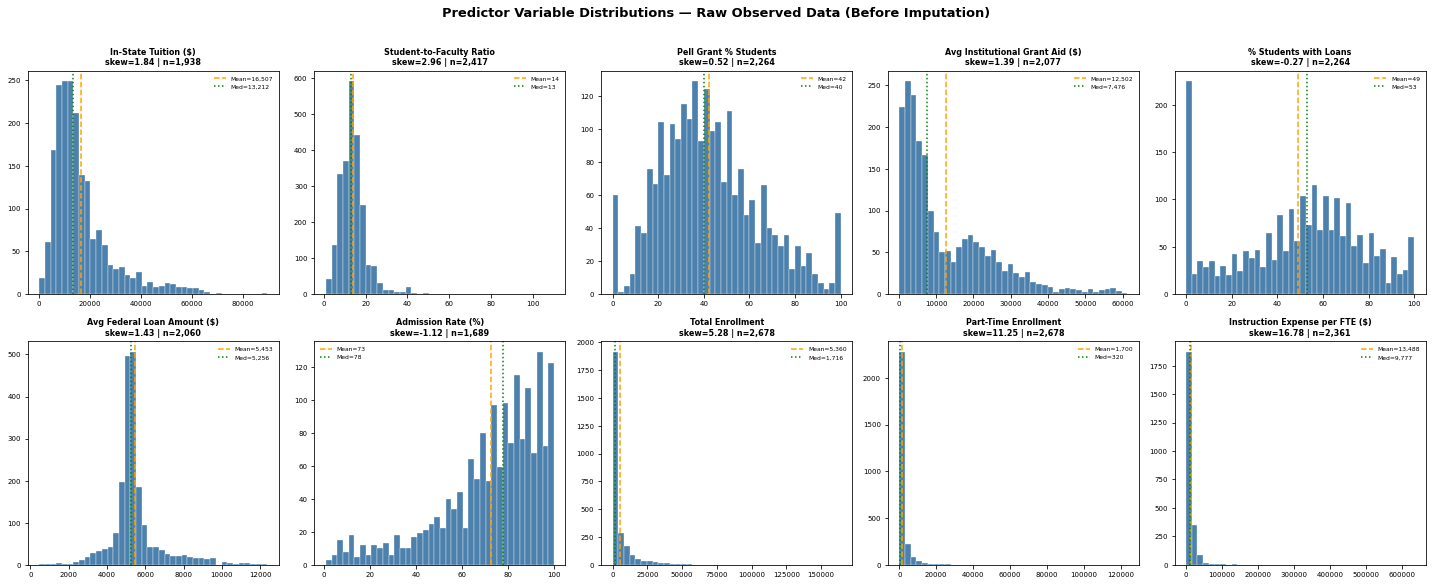

✔ Plot saved


In [169]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Predictor Variable Distributions — Raw Observed Data (Before Imputation)",
             fontsize=13, fontweight="bold", y=1.01)

PREDICTOR_LABELS = {
    "tuition"               : "In-State Tuition ($)",
    "student_faculty_ratio" : "Student-to-Faculty Ratio",
    "pell_pct"              : "Pell Grant % Students",
    "inst_grant_aid"        : "Avg Institutional Grant Aid ($)",
    "loan_pct"              : "% Students with Loans",
    "avg_fed_loan"          : "Avg Federal Loan Amount ($)",
    "admit_rate"            : "Admission Rate (%)",
    "total_enroll"          : "Total Enrollment",
    "parttime_enroll"       : "Part-Time Enrollment",
    "instr_exp_per_fte"     : "Instruction Expense per FTE ($)",
}

for ax, (col, label) in zip(axes.flat, PREDICTOR_LABELS.items()):
    data = df_observed[col].dropna()
    ax.hist(data, bins=40, color="#2D6A9F", edgecolor="white",
            linewidth=0.4, alpha=0.85)
    ax.axvline(data.mean(),   color="orange", linewidth=1.5,
               linestyle="--", label=f"Mean={data.mean():,.0f}")
    ax.axvline(data.median(), color="green",  linewidth=1.5,
               linestyle=":",  label=f"Med={data.median():,.0f}")
    skew = data.skew()
    n = len(data)
    ax.set_title(f"{label}\nskew={skew:.2f} | n={n:,}", fontsize=8, fontweight="bold")
    ax.legend(fontsize=6, frameon=False)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("predictor_distributions_raw.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

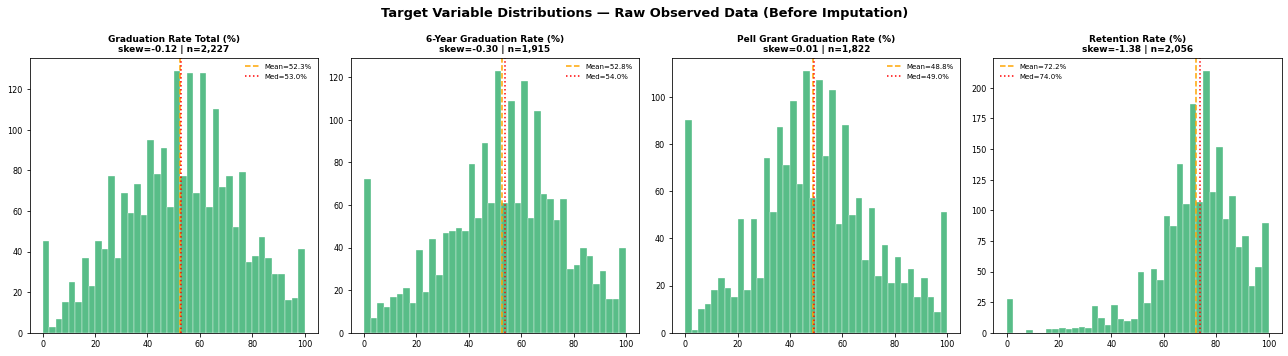

✔ Plot saved


In [170]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Target Variable Distributions — Raw Observed Data (Before Imputation)",
             fontsize=13, fontweight="bold")

TARGET_LABELS = {
    "grad_rate_total" : "Graduation Rate Total (%)",
    "grad_rate_6yr"   : "6-Year Graduation Rate (%)",
    "pell_grad_rate"  : "Pell Grant Graduation Rate (%)",
    "retention_rate"  : "Retention Rate (%)",
}

for ax, (col, label) in zip(axes.flat, TARGET_LABELS.items()):
    data = df_observed[col].dropna()
    ax.hist(data, bins=40, color="#3BB273", edgecolor="white",
            linewidth=0.4, alpha=0.85)
    ax.axvline(data.mean(),   color="orange", linewidth=1.5,
               linestyle="--", label=f"Mean={data.mean():.1f}%")
    ax.axvline(data.median(), color="red",    linewidth=1.5,
               linestyle=":",  label=f"Med={data.median():.1f}%")
    skew = data.skew()
    n = len(data)
    ax.set_title(f"{label}\nskew={skew:.2f} | n={n:,}", fontsize=9, fontweight="bold")
    ax.legend(fontsize=7, frameon=False)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("target_distributions_raw.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

### 6.3 Outlier Detection — Raw Observed Data

In [171]:
outlier_report_raw = []

for col in PREDICTOR_COLS:
    data = df_observed[col].dropna()
    q1  = data.quantile(0.25)
    q3  = data.quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - (1.5 * iqr)
    upper_fence = q3 + (1.5 * iqr)
    n_outliers  = ((data < lower_fence) | (data > upper_fence)).sum()

    outlier_report_raw.append({
        "variable"    : col,
        "n_observed"  : len(data),
        "Q1"          : round(q1, 1),
        "Q3"          : round(q3, 1),
        "IQR"         : round(iqr, 1),
        "lower_fence" : round(lower_fence, 1),
        "upper_fence" : round(upper_fence, 1),
        "n_outliers"  : n_outliers,
        "outlier_pct" : round(n_outliers / len(data) * 100, 1)
    })

outlier_df_raw = pd.DataFrame(outlier_report_raw).set_index("variable")
print("Outlier Detection — Raw Observed Data (before imputation):")
print(outlier_df_raw)

Outlier Detection — Raw Observed Data (before imputation):
                       n_observed      Q1       Q3      IQR  lower_fence  \
variable                                                                   
tuition                      1938  8910.0  19742.5  10832.5      -7338.8   
student_faculty_ratio        2417    10.0     17.0      7.0         -0.5   
pell_pct                     2264    27.0     55.2     28.2        -15.4   
inst_grant_aid               2077  3515.0  19636.0  16121.0     -20666.5   
loan_pct                     2264    30.0     69.0     39.0        -28.5   
avg_fed_loan                 2060  4970.8   5628.0    657.2       3984.9   
admit_rate                   1689    62.0     89.0     27.0         21.5   
total_enroll                 2678   516.0   5120.5   4604.5      -6390.8   
parttime_enroll              2678    52.2   1496.5   1444.2      -2114.1   
instr_exp_per_fte            2361  6971.0  14342.0   7371.0      -4085.5   

                       upper

### Interpretation — Raw Observed Data (Before Imputation)

**Sample Sizes Vary by Variable:**
Each variable has a different count reflecting its own missingness:
- total_enroll and parttime_enroll have the most observations (n=2,678)
- admit_rate has the fewest observations (n=1,689) — 37.8% missing
- tuition has only 1,938 observations — 28.7% missing
- This variation is expected and reflects the real reporting 
  patterns in the IPEDS dataset

**Skewness — Raw Observed Data:**

| Variable | Raw Skew | Interpretation |
|---|---|---|
| In-State Tuition | 1.84 | Right skewed |
| Student-to-Faculty Ratio | 2.96 | Strongly right skewed |
| Pell Grant % | 0.52 | Near symmetric |
| Institutional Grant Aid | 1.39 | Right skewed |
| % Students with Loans | -0.27 | Near symmetric |
| Avg Federal Loan | 1.43 | Right skewed |
| Admission Rate | -1.12 | Left skewed |
| Total Enrollment | 5.28 | Extremely right skewed |
| Part-Time Enrollment | 11.25 | Extremely right skewed |
| Instruction Expense per FTE | 16.78 | Most extreme skew |

**Outlier Detection — Raw Observed Data:**

| Variable | n Observed | n Outliers | Outlier % |
|---|---|---|---|
| avg_fed_loan | 2,060 | 385 | 18.7% |
| parttime_enroll | 2,678 | 344 | 12.8% |
| total_enroll | 2,678 | 322 | 12.0% |
| instr_exp_per_fte | 2,361 | 192 | 8.1% |
| tuition | 1,938 | 149 | 7.7% |
| admit_rate | 1,689 | 78 | 4.6% |
| student_faculty_ratio | 2,417 | 74 | 3.1% |
| inst_grant_aid | 2,077 | 55 | 2.6% |
| pell_pct | 2,264 | 49 | 2.2% |
| loan_pct | 2,264 | 0 | 0.0% |

**Key Observations:**
- The overall distributional shapes are consistent with 
  expectations — financial and enrollment variables are right 
  skewed while percentage variables are more symmetric
- Variables flagged for potential log transformation in Phase 3 
  based on raw skewness above 2.0: student_faculty_ratio (2.96), 
  total_enroll (5.28), parttime_enroll (11.25), and 
  instr_exp_per_fte (16.78)
- avg_fed_loan has the highest outlier percentage (18.7%) driven 
  by its narrow IQR of $657 — values are tightly clustered so 
  even small deviations are flagged
- loan_pct has zero outliers in the raw data confirming it is 
  the cleanest variable in the dataset
- These raw results will be compared against post-imputation 
  EDA to verify that imputation does not significantly distort 
  the distributions or outlier patterns

## 7. Handling Missing Values — Imputation

Two imputation strategies are applied to **predictor variables only**.
Target variables are intentionally left as-is — imputing outcome 
variables would mean inventing the values the model is trying to predict.
**Numeric predictors → Median imputation**

**Categorical predictors — two strategies:**
- `state`, `sector`, `control`, `level` → filled with "Unknown" 
  category rather than mode — mode imputation would falsely assign 
  institutions to real states or sectors
- `size_cat`, `locale` → Mode imputation as these are descriptive 
  ordinal categories

**Target variables (not imputed):**
- grad_rate_total
- grad_rate_6yr  
- pell_grad_rate
- retention_rate
A binary flag `admit_rate_missing` is created before imputation 
to capture institutions that did not report an admit rate.

Missing admit rate should not be interpreted as automatically 
indicating open admission. Non-reporting may occur for several 
reasons including:
- Open admissions policy
- Specialized admissions processes
- No first-time undergraduate cohort reported
- General non-reporting to IPEDS

The flag is named `admit_rate_missing` rather than `open_admission` 
to reflect this uncertainty. It will be used as a binary predictor 
in Phase 3 to capture this structural difference between institutions.


In [172]:
# ── Predictor columns only (targets excluded) ──────────────────────
NUM_COLS = ["tuition", "student_faculty_ratio", "pell_pct",
            "inst_grant_aid", "loan_pct", "avg_fed_loan",
            "admit_rate", "total_enroll",
            "parttime_enroll", "instr_exp_per_fte"]

# Categorical columns split into two groups based on imputation strategy
UNKNOWN_COLS = ["state", "sector", "control", "level"]
MODE_COLS    = ["size_cat", "locale"]

# ── admit_rate_missing flag ────────────────────────────────────────
# Named admit_rate_missing rather than open_admission because 
# missing admit rate does not definitively indicate open admission —
# it may also reflect non-reporting, specialized admissions processes,
# or no first-time undergraduate cohort reported to IPEDS
df_clean["admit_rate_missing"] = df_clean["admit_rate"].isnull().astype(int)
print(f"✔ admit_rate_missing flag created")
print(f"  Institutions with missing admit rate : {df_clean['admit_rate_missing'].sum():,}")
print(f"  Institutions with reported admit rate: {(df_clean['admit_rate_missing']==0).sum():,}")

# ── Median imputation for numeric predictors ───────────────────────
imputed_report = {}
for col in NUM_COLS:
    n_miss = df_clean[col].isnull().sum()
    if n_miss > 0:
        med = df_clean[col].median()
        df_clean[col].fillna(med, inplace=True)
        imputed_report[col] = {"n_imputed"  : n_miss,
                               "method"     : "median",
                               "value_used" : round(med, 2)}

# ── Unknown category for state/sector/control/level ────────────────
# Mode imputation would falsely assign institutions to real states 
# or sectors creating artificial category membership
# Unknown is more honest and preserves missingness as information
for col in UNKNOWN_COLS:
    n_miss = df_clean[col].isnull().sum()
    if n_miss > 0:
        df_clean[col].fillna("Unknown", inplace=True)
        imputed_report[col] = {"n_imputed"  : n_miss,
                               "method"     : "Unknown category",
                               "value_used" : "Unknown"}

# ── Mode imputation for size_cat and locale ────────────────────────
# These are descriptive ordinal categories where Unknown 
# is less meaningful than the most common category
for col in MODE_COLS:
    n_miss = df_clean[col].isnull().sum()
    if n_miss > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        imputed_report[col] = {"n_imputed"  : n_miss,
                               "method"     : "mode",
                               "value_used" : mode_val}

# ── Imputation summary ─────────────────────────────────────────────
print("\nImputation Summary:")
print(pd.DataFrame(imputed_report).T)

# ── Verify target variables still have missing values ──────────────
TARGET_COLS = ["grad_rate_total", "grad_rate_6yr",
               "pell_grad_rate", "retention_rate"]
print("\nTarget variables (missing values preserved — not imputed):")
print(df_clean[TARGET_COLS].isnull().sum())

✔ admit_rate_missing flag created
  Institutions with missing admit rate : 1,027
  Institutions with reported admit rate: 1,689

Imputation Summary:
                      n_imputed            method   value_used
tuition                     778            median      13212.0
student_faculty_ratio       299            median         13.0
pell_pct                    452            median         40.0
inst_grant_aid              639            median       7476.0
loan_pct                    452            median         53.0
avg_fed_loan                656            median       5255.5
admit_rate                 1027            median         78.0
total_enroll                 38            median       1716.5
parttime_enroll              38            median        320.0
instr_exp_per_fte           355            median       9777.0
state                        28  Unknown category      Unknown
sector                       28  Unknown category      Unknown
control                      28 

### Key Findings:
- 10 numeric predictor columns were imputed using median
- 4 categorical columns (state, sector, control, level) filled 
  with "Unknown" category to avoid false category assignment
- 2 categorical columns (size_cat, locale) filled using mode
- `admit_rate` received an additional `admit_rate_missing` flag 
  to capture non-random missingness — this reflects institutions 
  that did not report admit rates for various reasons and should 
  not be interpreted as definitively indicating open admission
- All 4 target variables retain their original missing values 
  — these rows will be dropped only at the modeling stage in Phase 3

## 8. EDA Part B — Post-Imputation Verification

After imputation is applied, the distributions and outlier 
patterns are compared against the raw observed data to verify 
that imputation did not significantly distort the dataset.

If skewness, means, medians, and outlier counts remain similar 
before and after imputation, the preprocessing is considered 
sound. Significant deviations would indicate that imputation 
introduced artificial patterns requiring investigation.

### 8.1 Raw vs Imputed — Statistical Comparison

In [173]:
comparison = []

for col in PREDICTOR_COLS:
    raw = df_observed[col].dropna()
    imp = df_clean[col]
    
    comparison.append({
        "variable"       : col,
        "raw_n"          : len(raw),
        "imputed_n"      : len(imp),
        "raw_mean"       : round(raw.mean(), 1),
        "imputed_mean"   : round(imp.mean(), 1),
        "mean_change_%"  : round((imp.mean() - raw.mean()) / raw.mean() * 100, 1) if raw.mean() != 0 else 0,
        "raw_median"     : round(raw.median(), 1),
        "imputed_median" : round(imp.median(), 1),
        "raw_skew"       : round(raw.skew(), 2),
        "imputed_skew"   : round(imp.skew(), 2),
        "skew_change"    : round(imp.skew() - raw.skew(), 2),
    })

comp_df = pd.DataFrame(comparison).set_index("variable")

print("Raw vs Imputed Comparison — Predictor Variables:")
print("="*80)
print(comp_df[["raw_n", "imputed_n", "raw_mean", "imputed_mean", 
               "mean_change_%"]].to_string())
print()
print(comp_df[["raw_median", "imputed_median", "raw_skew", 
               "imputed_skew", "skew_change"]].to_string())

Raw vs Imputed Comparison — Predictor Variables:
                       raw_n  imputed_n  raw_mean  imputed_mean  mean_change_%
variable                                                                      
tuition                 1938       2716   16507.0       15563.1           -5.7
student_faculty_ratio   2417       2716      14.0          13.9           -0.8
pell_pct                2264       2716      42.5          42.1           -1.0
inst_grant_aid          2077       2716   12502.0       11319.5           -9.5
loan_pct                2264       2716      49.0          49.7            1.3
avg_fed_loan            2060       2716    5453.1        5405.4           -0.9
admit_rate              1689       2716      72.6          74.7            2.8
total_enroll            2678       2716    5360.1        5309.1           -1.0
parttime_enroll         2678       2716    1700.5        1681.1           -1.1
instr_exp_per_fte       2361       2716   13487.8       13002.8           -3.6

  

### 8.2 Distribution Overlay — Raw vs Imputed

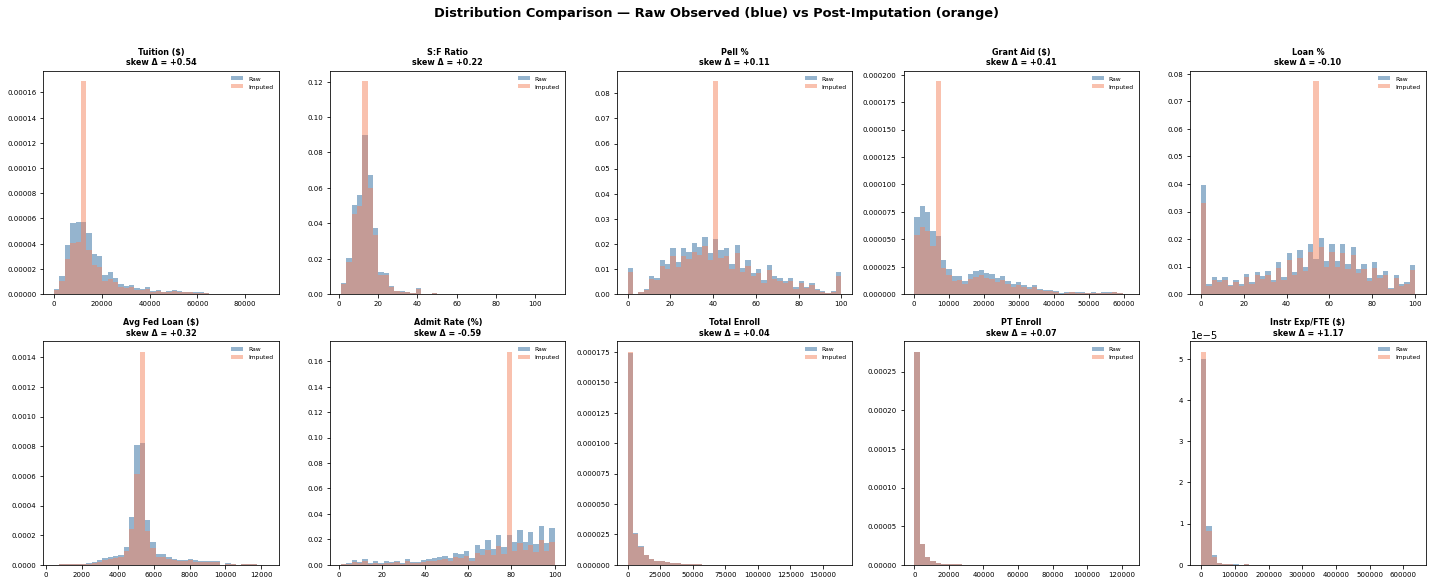

✔ Plot saved


In [174]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("Distribution Comparison — Raw Observed (blue) vs Post-Imputation (orange)",
             fontsize=13, fontweight="bold", y=1.01)

PRED_LABELS = {
    "tuition"               : "Tuition ($)",
    "student_faculty_ratio" : "S:F Ratio",
    "pell_pct"              : "Pell %",
    "inst_grant_aid"        : "Grant Aid ($)",
    "loan_pct"              : "Loan %",
    "avg_fed_loan"          : "Avg Fed Loan ($)",
    "admit_rate"            : "Admit Rate (%)",
    "total_enroll"          : "Total Enroll",
    "parttime_enroll"       : "PT Enroll",
    "instr_exp_per_fte"     : "Instr Exp/FTE ($)",
}

for ax, (col, label) in zip(axes.flat, PRED_LABELS.items()):
    raw = df_observed[col].dropna()
    imp = df_clean[col]
    
    ax.hist(raw, bins=40, alpha=0.5, color="#2D6A9F",
            label="Raw", density=True)
    ax.hist(imp, bins=40, alpha=0.5, color="#F4845F",
            label="Imputed", density=True)
    
    skew_change = round(imp.skew() - raw.skew(), 2)
    ax.set_title(f"{label}\nskew Δ = {skew_change:+.2f}",
                 fontsize=8, fontweight="bold")
    ax.legend(fontsize=6, frameon=False)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("raw_vs_imputed_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

### 8.3 Outlier Comparison — Raw vs Imputed

In [175]:
outlier_comparison = []

for col in PREDICTOR_COLS:
    raw = df_observed[col].dropna()
    q1_r, q3_r = raw.quantile([0.25, 0.75])
    iqr_r = q3_r - q1_r
    n_out_raw = ((raw < q1_r - 1.5*iqr_r) | (raw > q3_r + 1.5*iqr_r)).sum()
    
    imp = df_clean[col]
    q1_i, q3_i = imp.quantile([0.25, 0.75])
    iqr_i = q3_i - q1_i
    n_out_imp = ((imp < q1_i - 1.5*iqr_i) | (imp > q3_i + 1.5*iqr_i)).sum()
    
    outlier_comparison.append({
        "variable"        : col,
        "raw_outliers"    : n_out_raw,
        "raw_pct"         : round(n_out_raw / len(raw) * 100, 1),
        "imputed_outliers": n_out_imp,
        "imputed_pct"     : round(n_out_imp / len(imp) * 100, 1),
        "change"          : n_out_imp - n_out_raw,
    })

out_comp_df = pd.DataFrame(outlier_comparison).set_index("variable")
print("Outlier Comparison — Raw vs Imputed:")
print(out_comp_df.to_string())

Outlier Comparison — Raw vs Imputed:
                       raw_outliers  raw_pct  imputed_outliers  imputed_pct  change
variable                                                                           
tuition                         149      7.7               313         11.5     164
student_faculty_ratio            74      3.1               193          7.1     119
pell_pct                         49      2.2               120          4.4      71
inst_grant_aid                   55      2.6               149          5.5      94
loan_pct                          0      0.0                 0          0.0       0
avg_fed_loan                    385     18.7               580         21.4     195
admit_rate                       78      4.6               457         16.8     379
total_enroll                    322     12.0               327         12.0       5
parttime_enroll                 344     12.8               355         13.1      11
instr_exp_per_fte               192    

### Post-Imputation Verification

After median/mode imputation, summary statistics were checked to ensure
that preprocessing did not create impossible values or major distributional
distortions.

Median imputation preserved the central values of most numeric predictors,
but variables with high missingness, especially `admit_rate`, show visible
artifacts because many missing values were filled with the same median value.

For this reason, the raw observed EDA from Section 6 remains the authoritative
source for distribution shape, skewness, and outlier interpretation. The
post-imputation dataset is used only as a modeling-ready version of the data,
not as the basis for substantive EDA conclusions.


## 9. Outlier Detection — Box Plots by Control Type

Box plots are generated using the post-imputation dataset 
(df_clean) to show outlier patterns across institution 
control types — Public, Private not-for-profit, and 
Private for-profit.

**Note:** Outlier counts referenced below are from the 
post-imputation dataset. Raw observed outlier counts from 
Section 6.3 should be treated as the authoritative reference 
since median imputation narrows the IQR and artificially 
inflates outlier counts.

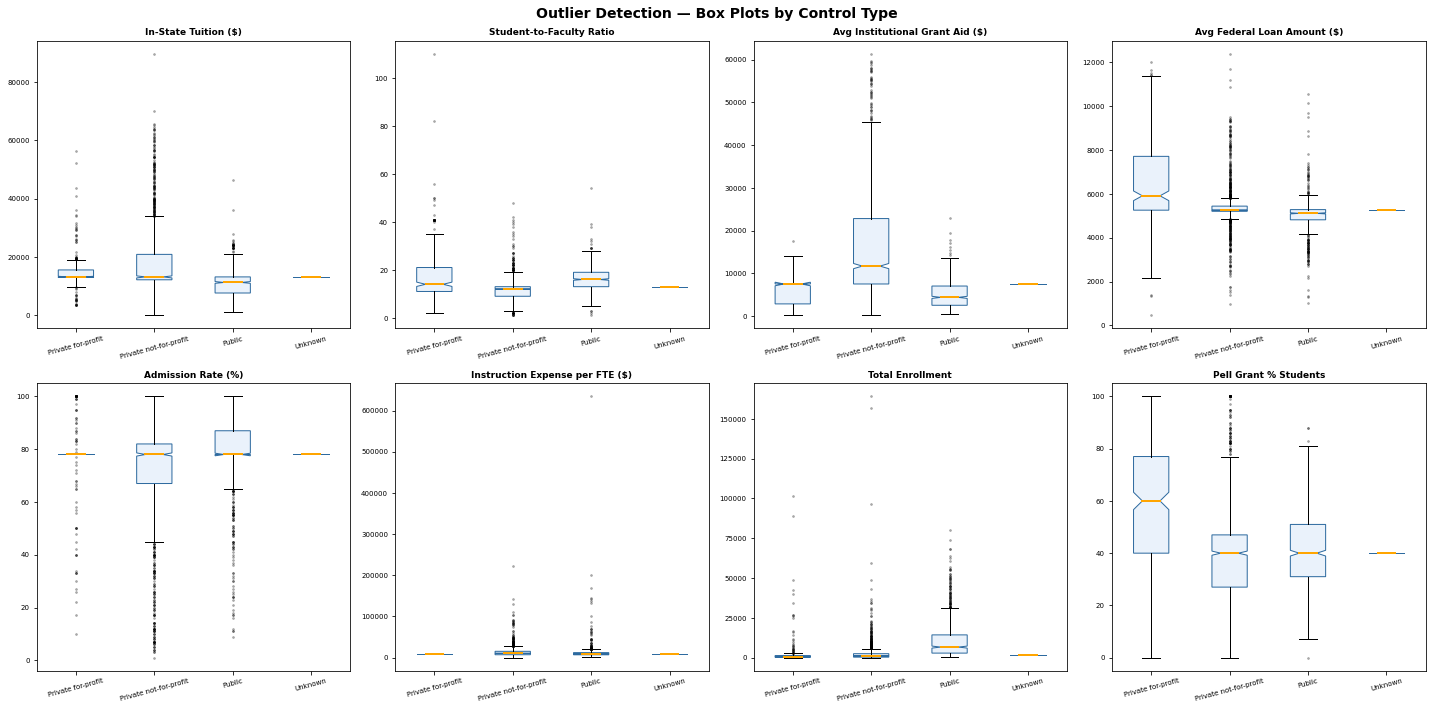

✔ Plot saved


In [176]:
BOX_VARS = ["tuition", "student_faculty_ratio", "inst_grant_aid",
            "avg_fed_loan", "admit_rate", "instr_exp_per_fte",
            "total_enroll", "pell_pct"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Outlier Detection — Box Plots by Control Type",
             fontsize=14, fontweight="bold")

LABELS = {
    "tuition"               : "In-State Tuition ($)",
    "student_faculty_ratio" : "Student-to-Faculty Ratio",
    "inst_grant_aid"        : "Avg Institutional Grant Aid ($)",
    "avg_fed_loan"          : "Avg Federal Loan Amount ($)",
    "admit_rate"            : "Admission Rate (%)",
    "instr_exp_per_fte"     : "Instruction Expense per FTE ($)",
    "total_enroll"          : "Total Enrollment",
    "pell_pct"              : "Pell Grant % Students",
}

for ax, col in zip(axes.flat, BOX_VARS):
    data_dict = {ctrl: grp[col].dropna().values
                 for ctrl, grp in df_clean.groupby("control")}
    ax.boxplot(data_dict.values(),
               labels=data_dict.keys(),
               patch_artist=True,
               notch=True,
               boxprops=dict(facecolor="#EAF2FB", color="#2D6A9F"),
               medianprops=dict(color="orange", linewidth=2),
               flierprops=dict(marker=".", color="red", 
                               alpha=0.4, markersize=3))
    ax.set_title(LABELS[col], fontsize=9, fontweight="bold")
    ax.tick_params(axis="x", labelsize=7, rotation=15)
    ax.tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("outlier_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

### Interpretation — Outlier Detection Results

**Tuition — 313 outliers (11.5%)**
- Normal range: $1,641 to $25,557
- 313 institutions fall above the upper fence of $25,557
- Box plot shows private not-for-profit schools have the widest 
  spread and most outliers — elite private universities charging 
  up to $89,550 drive this
- Public schools are tightly clustered with fewer outliers

**Student-to-Faculty Ratio — 193 outliers (7.1%)**
- Normal range: 3.5 to 23.5
- 193 institutions fall above the upper fence of 23.5
- Box plot confirms one extreme outlier above 100 — likely a 
  large online institution with very few faculty
- Private for-profit schools show the most extreme outliers here

**Pell Grant % — 120 outliers (4.4%)**
- Normal range: up to 82.5%
- 120 institutions have unusually high Pell % above 82.5%
- Box plot shows private for-profit schools have the highest 
  median Pell % — serving the most low income students
- Public schools cluster around 40% with moderate spread

**Institutional Grant Aid — 149 outliers (5.5%)**
- Normal range: up to $32,648
- 149 institutions award unusually high grant aid above $32,648
- Box plot shows private not-for-profit schools dominate here —
  they award the most aid with the widest spread going up to $61,290
- Public and for-profit schools award much lower grant aid

**Loan % — 0 outliers (0.0%)**
- The cleanest variable in the dataset — no outliers at all
- Values fall naturally within the IQR range across all 
  institution types
- Box plot confirms consistent spread across all control types

**Avg Federal Loan Amount — 580 outliers (21.4%)**
- Normal range: $4,542 to $5,983
- The highest outlier count of all variables at 21.4%
- This is because the IQR is very narrow ($360) — loan amounts 
  are tightly clustered around $5,000 so even small deviations 
  get flagged
- Box plot shows private for-profit schools have the widest 
  spread and highest average loan amounts — up to $12,370
- This high outlier count is a statistical artifact of the 
  narrow IQR rather than a true data quality problem

**Admission Rate — 457 outliers (16.8%)**
- Normal range: 58% to 98%
- 457 institutions fall outside this range
- Most outliers are below the lower fence of 58% — highly 
  selective schools with very low admit rates
- Box plot shows private not-for-profit schools have the widest 
  spread — ranging from highly selective to open admission

**Total Enrollment — 327 outliers (12.0%)**
- Normal range: up to 11,793 students
- 327 large institutions exceed this threshold
- Box plot confirms public schools have the largest enrollment 
  outliers — large state universities with over 100,000 students
- Private schools are much more tightly clustered at smaller sizes

**Part-Time Enrollment — 355 outliers (13.1%)**
- Normal range: up to 3,559 part-time students
- 355 institutions exceed this threshold
- Box plot shows public schools have the most extreme outliers 
  driven by large community college style programs within 
  4-year institutions

**Instruction Expense per FTE — 257 outliers (9.5%)**
- Normal range: up to $22,074
- 257 institutions spend above this threshold
- Box plot reveals one extreme outlier near $634,215 in the 
  private not-for-profit category — a very small specialized 
  research institution
- Private not-for-profit schools generally spend more per 
  student than public or for-profit schools

---
**Summary — Outlier Treatment Strategy for Phase 3:**

| Variable | Outlier % | Treatment |
|---|---|---|
| avg_fed_loan | 21.4% | Keep — narrow IQR artifact |
| admit_rate | 16.8% | Keep — admit_rate_missing flag handles this |
| parttime_enroll | 13.1% | Log transform in Phase 3 |
| total_enroll | 12.0% | Log transform in Phase 3 |
| tuition | 11.5% | Keep — legitimate variation |
| instr_exp_per_fte | 9.5% | Log transform in Phase 3 |
| student_faculty_ratio | 7.1% | Investigate extreme value |
| inst_grant_aid | 5.5% | Keep — legitimate variation |
| pell_pct | 4.4% | Keep — legitimate variation |
| loan_pct | 0.0% | No action needed |

Tree based models (Random Forest, XGBoost) handle outliers 
naturally. Log transformation is only needed for linear 
regression models in Phase 3.

## 10. Feature Engineering

Two new features are created from existing variables to capture 
relationships that raw numbers alone cannot express.
These features are created here for use in the correlation analysis 
in Section 12. They will be formally developed and evaluated in 
Phase 2 using permutation importance.

---

### Affordability Index = Institutional Grant Aid ÷ Avg Federal Loan

- Measures how much institutional support a school provides 
  relative to how much students need to borrow
- A value above 1.0 means the school gives more in grant aid 
  than students need to borrow — indicating strong financial support
- A value below 1.0 means students are borrowing more than 
  the school provides — indicating financial strain

**Note:** The original formulation used tuition as the denominator 
(Institutional Grant Aid ÷ Tuition). However the IPEDS tuition field 
represents raw unadjusted base tuition only and does not reflect true 
cost of attendance for all institutions due to differential mandatory 
fee reporting practices — a known IPEDS reporting artifact. Average 
federal loan amount is used as the denominator instead as it is a 
more reliable and consistent measure across all institution types.

---

### Part-Time Share = Part-Time Enrollment ÷ Total Enrollment

- Captures the character of the student body more meaningfully 
  than raw part-time enrollment numbers alone
- A value of 0.0 means all students attend full time
- A value of 1.0 means all students attend part time
- Higher part-time share is associated with longer time to 
  degree and higher dropout rates
- The most reliable of the two engineered features — no 
  reporting artifacts or data limitations apply

In [177]:

## ── Affordability Index ────────────────────────────────────────────
# institutional grant aid relative to average federal loan amount
# Higher value = school covers more relative to what students borrow
# Avoids the unreliable IPEDS tuition field entirely
df_clean["affordability_index"] = (
    df_clean["inst_grant_aid"] /
    df_clean["avg_fed_loan"].replace(0, np.nan)
)
df_observed["affordability_index"] = (
    df_observed["inst_grant_aid"] /
    df_observed["avg_fed_loan"].replace(0, np.nan)
)

# ── Part-Time Share ────────────────────────────────────────────────
# part time students as proportion of total enrollment
# Higher value = more part time students = associated with lower grad rates
# Most reliable engineered feature — no reporting artifacts apply
df_clean["parttime_share"] = (
    df_clean["parttime_enroll"] /
    df_clean["total_enroll"].replace(0, np.nan)
)
df_observed["parttime_share"] = (
    df_observed["parttime_enroll"] /
    df_observed["total_enroll"].replace(0, np.nan)
)

# ── Summary ────────────────────────────────────────────────────────
print("Engineered Features Summary (df_clean — imputed dataset):")
print(df_clean[["affordability_index",
                "parttime_share"]].describe().round(3))

print(f"\nNaN in affordability_index : {df_clean['affordability_index'].isnull().sum()}")
print(f"NaN in parttime_share      : {df_clean['parttime_share'].isnull().sum()}")

Engineered Features Summary (df_clean — imputed dataset):
       affordability_index  parttime_share
count             2716.000        2716.000
mean                 2.188           0.283
std                  2.232           0.244
min                  0.015           0.000
25%                  0.836           0.084
50%                  1.423           0.222
75%                  2.895           0.421
max                 16.921           1.000

NaN in affordability_index : 0
NaN in parttime_share      : 0


### Interpretation — Engineered Features

**Affordability Index (inst_grant_aid ÷ avg_fed_loan):**
- A median of 1.423 indicates that a typical institution provides 
  42% more in grant aid than the average amount students borrow
- Values above 1.0 indicate the school provides more in grant aid 
  than students borrow on average
- Values below 1.0 indicate students are borrowing more than the 
  school provides in grant aid
- Max of 16.9 represents highly generous institutions providing 
  far more aid relative to student borrowing need
- Higher affordability scores are positively associated with 
  graduation rates — though this relationship may also reflect 
  institutional wealth, selectivity, and student composition


**Part-Time Share (parttime_enroll ÷ total_enroll):**
- A median of 0.222 indicates a typical institution has 22% 
  part time students
- Values range from 0.0 (entirely full time) to 1.0 (entirely 
  part time)
- Higher part-time share is negatively associated with graduation 
  rates — part time students typically take longer to complete 
  degrees and face higher dropout risk
- No NaN values — complete coverage across all 2,716 institutions

## 11. State-Level Variation

State-level analysis examines whether graduation rates and other 
outcomes vary systematically across states. This is important because:
- State funding levels for public universities differ significantly
- Demographics and economic conditions vary by state
- Policy environments differ across states

If significant state-level variation exists it must be accounted 
for in the regression models in Phase 3.

In [178]:
# ── State level aggregation ────────────────────────────────────────
state_agg = (df_clean.groupby("state")[
    ["grad_rate_6yr", "retention_rate", "tuition", "pell_pct"]]
    .agg(["mean", "count"])
    .round(1))

state_agg.columns = ["_".join(c) for c in state_agg.columns]
state_sorted = state_agg.sort_values("grad_rate_6yr_mean", ascending=False)

print("Top 10 States by Mean 6-Year Graduation Rate:")
print(state_sorted["grad_rate_6yr_mean"].head(10).to_string())

print("\nBottom 10 States by Mean 6-Year Graduation Rate:")
print(state_sorted["grad_rate_6yr_mean"].tail(10).to_string())

Top 10 States by Mean 6-Year Graduation Rate:
state
Connecticut      67.3
Massachusetts    67.1
Rhode Island     66.5
Vermont          62.0
Wyoming          61.0
Minnesota        60.1
California       59.6
Iowa             59.3
Washington       59.3
New Hampshire    59.1

Bottom 10 States by Mean 6-Year Graduation Rate:
state
Alabama       42.4
Georgia       41.7
New Jersey    41.4
Delaware      41.2
Arkansas      40.4
Alaska        40.2
Oklahoma      39.6
New Mexico    37.1
Nevada        35.9
Unknown        NaN


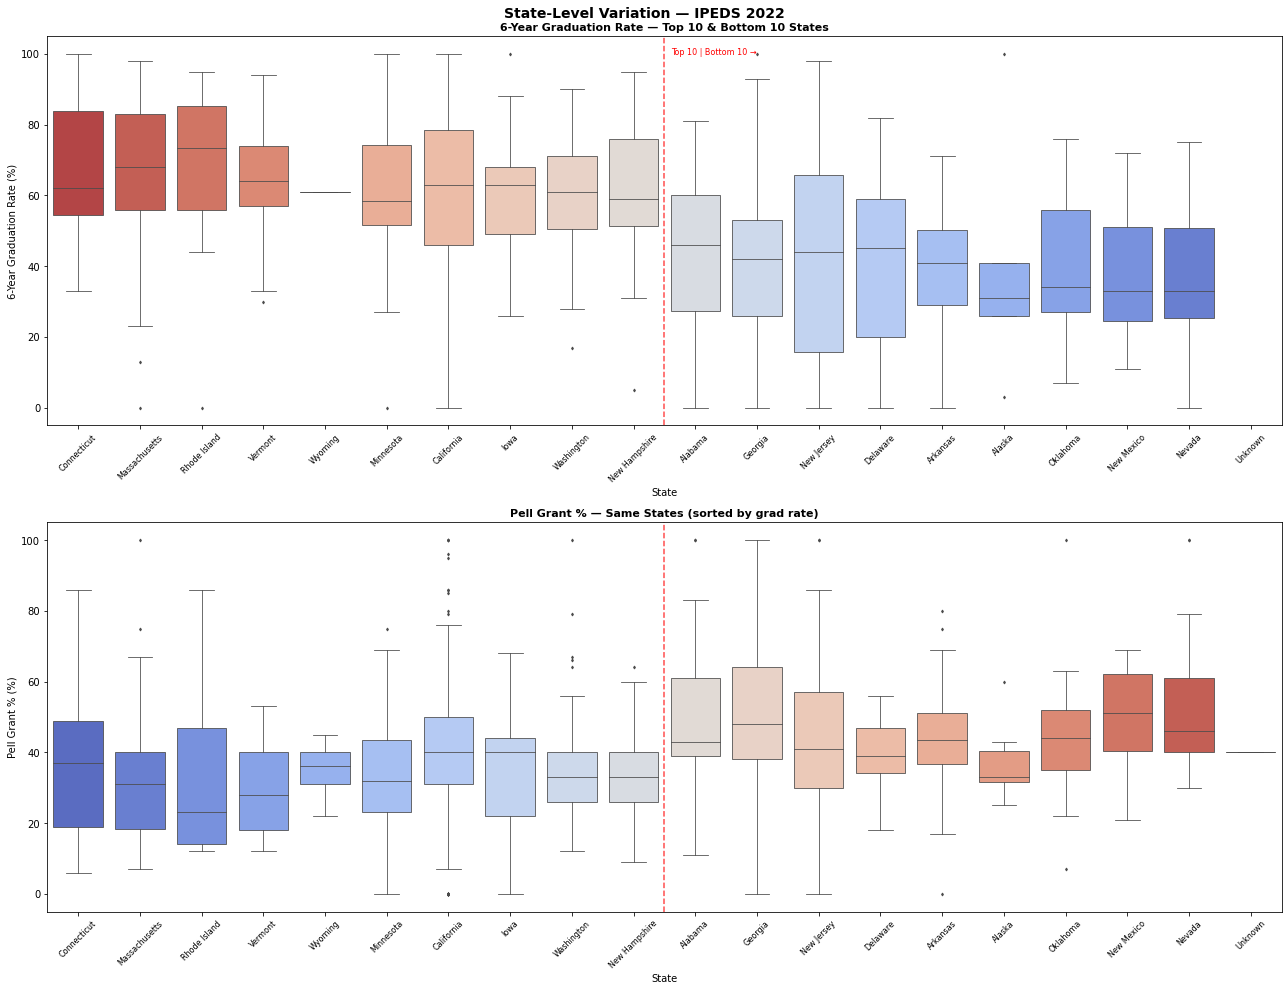

✔ Plot saved


In [179]:
# ── Plot state variation ───────────────────────────────────────────
top10_states = state_sorted.index[:10].tolist()
bot10_states = state_sorted.index[-10:].tolist()
show_states  = top10_states + bot10_states

state_plot = df_clean[df_clean["state"].isin(show_states)].copy()
order = (state_sorted.loc[show_states, "grad_rate_6yr_mean"]
         .sort_values(ascending=False).index)

fig, axes = plt.subplots(2, 1, figsize=(18, 14))
fig.suptitle("State-Level Variation — IPEDS 2022",
             fontsize=14, fontweight="bold")

# Box plot — 6yr grad rate by state
sns.boxplot(data=state_plot, x="state", y="grad_rate_6yr",
            order=order, palette="coolwarm_r", ax=axes[0],
            linewidth=0.8, fliersize=2)
axes[0].set_title("6-Year Graduation Rate — Top 10 & Bottom 10 States",
                   fontweight="bold", fontsize=11)
axes[0].set_xlabel("State", fontsize=10)
axes[0].set_ylabel("6-Year Graduation Rate (%)", fontsize=10)
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].axvline(9.5, color="red", linewidth=1.5,
                linestyle="--", alpha=0.7)
axes[0].text(9.6, axes[0].get_ylim()[1]*0.95,
             "Top 10 | Bottom 10 →",
             fontsize=8, color="red")

# Box plot — Pell % by state
sns.boxplot(data=state_plot, x="state", y="pell_pct",
            order=order, palette="coolwarm", ax=axes[1],
            linewidth=0.8, fliersize=2)
axes[1].set_title("Pell Grant % — Same States (sorted by grad rate)",
                   fontweight="bold", fontsize=11)
axes[1].set_xlabel("State", fontsize=10)
axes[1].set_ylabel("Pell Grant % (%)", fontsize=10)
axes[1].tick_params(axis="x", rotation=45, labelsize=8)
axes[1].axvline(9.5, color="red", linewidth=1.5,
                linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("state_variation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

Mean Outcomes by Control Type:
                        grad_rate_6yr  retention_rate  tuition  pell_pct
control                                                                 
Private for-profit               39.1            62.8  14941.6      57.5
Private not-for-profit           55.7            74.1  18167.1      39.2
Public                           50.4            71.6  10963.8      41.8
Unknown                           NaN             NaN  13212.0      40.0


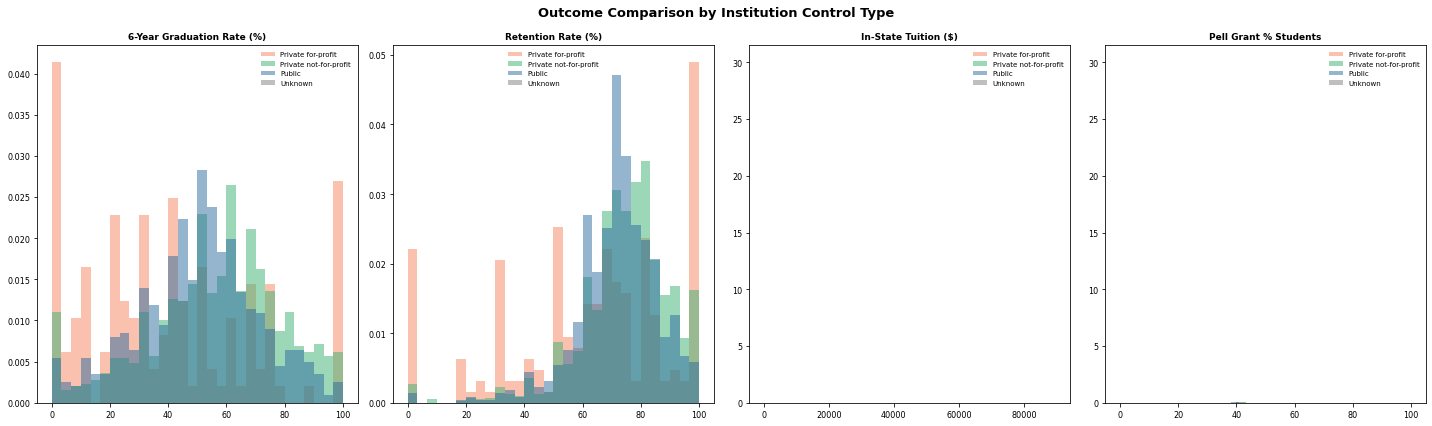

✔ Plot saved


In [180]:
# ── Outcome comparison by control type ────────────────────────────
print("Mean Outcomes by Control Type:")
ctrl_summary = (df_clean.groupby("control")[
    ["grad_rate_6yr", "retention_rate", "tuition", "pell_pct"]]
    .mean().round(1))
print(ctrl_summary.to_string())

# ── Plot control type comparison ───────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle("Outcome Comparison by Institution Control Type",
             fontsize=13, fontweight="bold")

CTRL_VARS = {
    "grad_rate_6yr"  : "6-Year Graduation Rate (%)",
    "retention_rate" : "Retention Rate (%)",
    "tuition"        : "In-State Tuition ($)",
    "pell_pct"       : "Pell Grant % Students",
}

colors = {"Public"               : "#2D6A9F",
          "Private not-for-profit": "#3BB273",
          "Private for-profit"   : "#F4845F"}

for ax, (col, label) in zip(axes, CTRL_VARS.items()):
    for ctrl, grp in df_clean.groupby("control"):
        ax.hist(grp[col].dropna(), bins=30, alpha=0.5,
                label=ctrl, color=colors.get(ctrl, "gray"),
                density=True)
    ax.set_title(label, fontweight="bold", fontsize=9)
    ax.legend(fontsize=7, frameon=False)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig("control_type_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

### Interpretation — State-Level Variation

**6-Year Graduation Rate by State:**

The top plot reveals dramatic variation in graduation rates across states.
The red dashed line separates the top 10 from the bottom 10 states.

Top performing states are dominated by New England:
- Connecticut (67.3%), Massachusetts (67.1%), Rhode Island (66.5%) 
  and New Hampshire (59.1%) all appear in the top 10
- These states are associated with well funded institutions, 
higher household incomes, and strong academic traditions — 
though the specific drivers of this pattern require further 
investigation

Bottom performing states show consistently lower outcomes:
- Nevada (35.9%), New Mexico (37.1%), and Oklahoma (39.6%) 
  are the lowest performing states
- These states tend to be associated with lower state funding, 
higher proportions of first generation college students, and 
more open admission institutions

The gap between the best and worst performing states is 31.4 
percentage points. However state averages are unweighted 
institutional means — a small college counts equally to a large 
state university. States with few institutions such as Wyoming 
may produce unstable estimates. Enrollment-weighted averages 
are recommended as a robustness check.
**Pell Grant % by State (bottom plot):**

The bottom plot shows Pell Grant % for the same states sorted 
by graduation rate. A clear inverse pattern emerges:
- Top performing states (left side) tend to have LOWER Pell % 
  — indicating fewer low income students
- Bottom performing states (right side) tend to have HIGHER Pell % 
  — indicating more low income students
- This pattern is consistent with state level graduation rate 
  differences being partly associated with the socioeconomic 
  composition of the student population rather than institutional 
  quality alone — though this interpretation is exploratory and 
  not a causal claim

---

### Interpretation — Outcomes by Control Type

From the table and plots:

| Control Type | Grad Rate 6yr | Retention | Tuition | Pell % |
|---|---|---|---|---|
| Private not-for-profit | 55.7% | 74.1% | $18,080 | 39.2% |
| Public | 50.4% | 71.6% | $10,964 | 41.8% |
| Private for-profit | 39.1% | 62.8% | $14,942 | 57.5% |

**Three key findings:**

**1. Private not-for-profit schools have the best outcomes:**
- Highest graduation rate (55.7%) and retention rate (74.1%)
- Despite charging the most in tuition ($18,080)
- They serve fewer Pell Grant students (39.2%) — a less 
  financially vulnerable student population
- The histograms show their graduation rates cluster between 
  50% and 80% — consistently strong performance

**2. Public schools are the most affordable but lag behind:**
- Lowest tuition at $10,964 — most accessible financially
- Graduation rate of 50.4% — below private not-for-profits
- Similar Pell % to private not-for-profits (41.8%)
- Their histograms show the widest spread — ranging from 
  very low to very high performers

**3. Private for-profit schools show the worst outcomes:**
- Lowest graduation rate (39.1%) and retention rate (62.8%)
- Serve the highest proportion of Pell Grant students (57.5%)
  — the most financially vulnerable student population
- Charge more than public schools ($14,942) despite worse outcomes
- Their graduation rate histogram shows a heavy concentration 
  near 0-20% — many students do not complete their degrees
- This pattern is well documented in higher education research 
  and raises serious questions about value for money

**Overall finding:**
Institution control type is a significant predictor of student 
outcomes. Private for-profit institutions consistently underperform 
relative to their cost — a pattern that will be formally tested 
in the regression models in Phase 3.

## 12. Correlation Analysis

Correlation analysis examines the linear relationship between 
pairs of numeric variables. The Pearson correlation coefficient 
(r) ranges from -1 to +1:

- r close to +1 → strong positive relationship
- r close to  0 → no linear relationship
- r close to -1 → strong negative relationship

Two visualizations are produced:
1. A full correlation heatmap showing all pairwise correlations
2. A ranked bar chart showing correlations with the primary 
   target variable (6-year graduation rate)

Note: Correlation measures association not causation.
A strong correlation does not mean one variable causes the other.

In [181]:
CORR_VARS = ["tuition", "student_faculty_ratio", "pell_pct",
             "inst_grant_aid", "loan_pct", "avg_fed_loan",
             "admit_rate", "total_enroll", "instr_exp_per_fte",
             "affordability_index",
             "parttime_share", "grad_rate_total", "grad_rate_6yr",
             "pell_grad_rate", "retention_rate"]

CORR_LABELS = {
    "tuition"               : "Tuition",
    "student_faculty_ratio" : "S:F Ratio",
    "pell_pct"              : "Pell %",
    "inst_grant_aid"        : "Inst. Grant Aid",
    "loan_pct"              : "Loan %",
    "avg_fed_loan"          : "Avg Fed Loan",
    "admit_rate"            : "Admit Rate",
    "total_enroll"          : "Total Enroll",
    "instr_exp_per_fte"     : "Instr Exp/FTE",
    "affordability_index"   : "Affordability Idx",
    "parttime_share"        : "Part-Time Share",
    "grad_rate_total"       : "Grad Rate Total",
    "grad_rate_6yr"         : "Grad Rate 6yr",
    "pell_grad_rate"        : "Pell Grad Rate",
    "retention_rate"        : "Retention Rate",
}

corr_matrix = df_clean[CORR_VARS].corr()
labels = [CORR_LABELS.get(c, c) for c in CORR_VARS]

print("Correlation matrix computed successfully")
print(f"Shape: {corr_matrix.shape}")

Correlation matrix computed successfully
Shape: (15, 15)


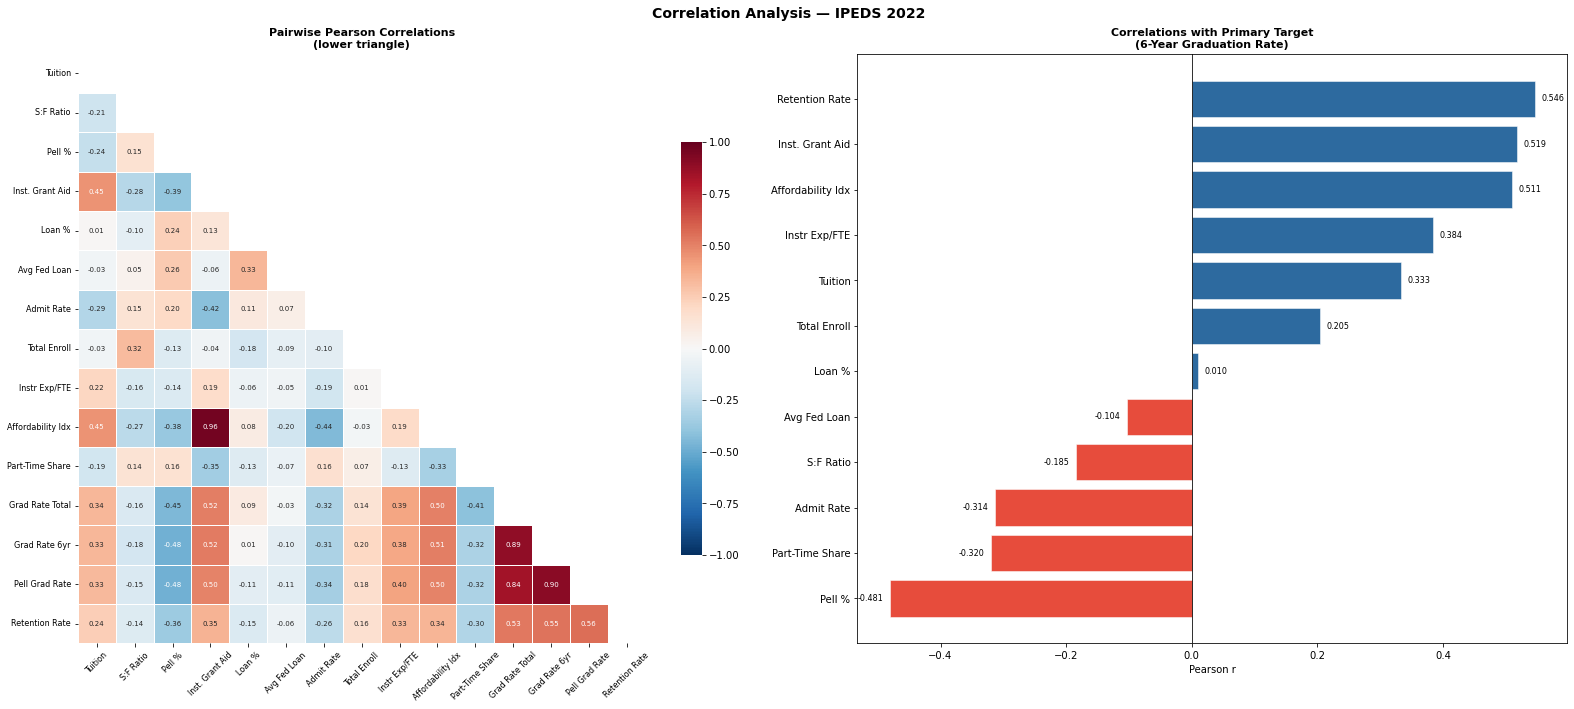

✔ Plot saved


In [182]:
# ── Full correlation heatmap ───────────────────────────────────────
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
fig.suptitle("Correlation Analysis — IPEDS 2022",
             fontsize=14, fontweight="bold")

# Lower triangle mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, ax=axes[0],
            xticklabels=labels, yticklabels=labels,
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.7})
axes[0].set_title("Pairwise Pearson Correlations\n(lower triangle)",
                   fontweight="bold", fontsize=11)
axes[0].tick_params(axis="x", rotation=45, labelsize=8)
axes[0].tick_params(axis="y", labelsize=8)

# ── Ranked bar chart — correlations with grad_rate_6yr ────────────
target_corr = (corr_matrix["grad_rate_6yr"]
               .drop(["grad_rate_6yr", "grad_rate_total", "pell_grad_rate"])
               .sort_values())

colors_bar = ["#E74C3C" if v < 0 else "#2D6A9F" 
              for v in target_corr]

axes[1].barh([CORR_LABELS.get(c, c) for c in target_corr.index],
             target_corr.values,
             color=colors_bar, edgecolor="white", linewidth=0.5)
axes[1].axvline(0, color="black", linewidth=0.8)

for i, v in enumerate(target_corr.values):
    axes[1].text(v + (0.01 if v >= 0 else -0.01), i,
                 f"{v:.3f}", va="center",
                 ha="left" if v >= 0 else "right", fontsize=8)

axes[1].set_title("Correlations with Primary Target\n(6-Year Graduation Rate)",
                   fontweight="bold", fontsize=11)
axes[1].set_xlabel("Pearson r", fontsize=10)

plt.tight_layout()
plt.savefig("correlations.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

In [183]:
# ── Print ranked correlations with primary target ──────────────────
print("Ranked Correlations with 6-Year Graduation Rate:")
print("="*50)
ranked = (corr_matrix["grad_rate_6yr"]
          .drop(["grad_rate_6yr", "grad_rate_total", "pell_grad_rate"])
          .sort_values(ascending=False))

for var, r in ranked.items():
    direction = "↑ positive" if r > 0 else "↓ negative"
    print(f"  {CORR_LABELS.get(var,var):20s}  r = {r:+.3f}  {direction}")

Ranked Correlations with 6-Year Graduation Rate:
  Retention Rate        r = +0.546  ↑ positive
  Inst. Grant Aid       r = +0.519  ↑ positive
  Affordability Idx     r = +0.511  ↑ positive
  Instr Exp/FTE         r = +0.384  ↑ positive
  Tuition               r = +0.333  ↑ positive
  Total Enroll          r = +0.205  ↑ positive
  Loan %                r = +0.010  ↑ positive
  Avg Fed Loan          r = -0.104  ↓ negative
  S:F Ratio             r = -0.185  ↓ negative
  Admit Rate            r = -0.314  ↓ negative
  Part-Time Share       r = -0.320  ↓ negative
  Pell %                r = -0.481  ↓ negative


### Interpretation — Correlation Analysis

---

#### Heatmap Observations

**Strong positive correlations (dark blue):**
- grad_rate_total ↔ grad_rate_6yr (r = 0.89) — these two target 
  variables are almost identical confirming only one should be 
  used as the primary target in Phase 3 modeling
- grad_rate_6yr ↔ pell_grad_rate (r = 0.84) — Pell graduation 
  rate closely tracks overall graduation rate
- affordability_index ↔ inst_grant_aid (r = 0.96) — very high 
  correlation since affordability index is derived from grant aid
  This indicates potential multicollinearity — only one of these 
  should be used as a predictor in linear models in Phase 3

**Strong negative correlations (dark red):**
- pell_pct ↔ inst_grant_aid (r = -0.39) — schools with more 
  low income students tend to give less institutional grant aid
- admit_rate ↔ inst_grant_aid (r = -0.44) — more selective 
  schools tend to give more grant aid

---

#### Ranked Correlations with 6-Year Graduation Rate

**Top positive predictors:**

**Retention Rate — r = +0.546 (strongest predictor)**
- Students who return for sophomore year are far more likely 
  to graduate within 6 years
- This is the single strongest predictor in the dataset
- Retention and graduation are deeply linked — early intervention 
  programs that improve retention will likely improve graduation

**Institutional Grant Aid — r = +0.519**
- Schools that invest more in student financial support see 
  significantly better graduation outcomes
- Financial barriers are a major driver of student dropout
- More generous aid directly reduces financial stress on students

**Affordability Index — r = +0.511**
- Schools where grant aid covers more of the borrowing need 
  produce better graduation outcomes
- Note: affordability_index and inst_grant_aid are highly 
  correlated (r = 0.96) — only one will be used in Phase 3 
  to avoid multicollinearity

**Instruction Expense per FTE — r = +0.384**
- Schools that invest more in teaching resources per student 
  produce better outcomes
- Higher spending likely reflects smaller classes, better 
  faculty, and stronger academic support

**Tuition — r = +0.333**
- Higher tuition schools tend to have better graduation rates
- This is NOT because charging more causes better outcomes
- More likely: expensive schools tend to be well resourced, 
  selective, and give generous financial aid — those factors 
  drive graduation not the price itself
- Classic example of correlation not implying causation

**Total Enrollment — r = +0.205**
- Larger institutions tend to have slightly better graduation rates
- Larger schools may have more resources and support services

---

**Top negative predictors:**

**Pell % — r = -0.481 (strongest negative predictor)**
- Schools with more low income students have lower graduation rates
- This reflects financial stress, working while studying, and 
  lack of family support networks — not academic ability
- This is the equity gap finding central to your research question

**Part-Time Share — r = -0.320**
- Schools with more part time students have lower graduation rates
- Part time students take longer to complete degrees and face 
  higher dropout risk due to work and family obligations

**Admit Rate — r = -0.314**
- More selective schools (lower admit rate) have higher graduation rates
- Selective schools admit students already set up to succeed 
  academically — this is called selection bias
- The model in Phase 3 must account for this carefully

**S:F Ratio — r = -0.185**
- Schools with more students per faculty member have lower 
  graduation rates
- Fewer faculty relative to students means less academic support 
  and mentorship

**Avg Fed Loan — r = -0.104**
- Weak negative relationship — higher average loan amounts 
  are slightly associated with lower graduation rates

**Loan % — r = +0.010**
- Virtually no linear relationship with graduation rates
- Whether students take loans matters less than how much 
  they borrow relative to the support they receive

---

#### Key Takeaways for Phase 3 Modeling

1. **Retention rate** is the strongest single predictor — 
   consider using it carefully as it may partially overlap 
   with the graduation rate target (students who leave never 
   graduate — some correlation is mechanical)

2. **Multicollinearity warning** — affordability_index and 
   inst_grant_aid are nearly identical (r = 0.96). Only one 
   should enter linear regression models in Phase 3

3. **The equity story is clear** — Pell % is the strongest 
   negative predictor confirming that low income students face 
   systematic disadvantages in graduation outcomes across 
   all institution types

4. **Tuition is positively correlated** with graduation rate 
   but this reflects institutional resources not price effects 
   — an important distinction for policy interpretation

5. **grad_rate_total and grad_rate_6yr are nearly identical** 
   (r = 0.89) — grad_rate_6yr will be used as the sole 
   primary target in Phase 3

### 12.1 Within-Institution Equity Gap Analysis

The equity gap between overall graduation rates and Pell Grant 
recipient graduation rates is calculated at the institution level.

This is more rigorous than comparing overall medians across 
different subsets of institutions — it measures the actual 
gap within each school that reports both values.

Institutions with both grad_rate_6yr and pell_grad_rate: 1,822

Equity Gap (grad_rate_6yr - pell_grad_rate):
count    1822.0
mean        4.3
std        10.1
min       -78.0
25%         1.0
50%         5.0
75%         9.0
max        81.0
Name: equity_gap, dtype: float64

Schools where Pell students graduate at LOWER rate: 1,376 (75.5%)
Schools where Pell students graduate at HIGHER rate: 287 (15.8%)
Schools where rates are equal:                       159 (8.7%)


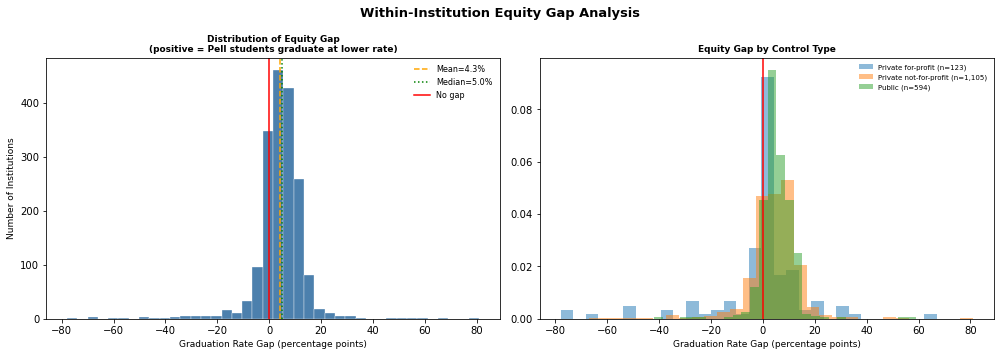

✔ Plot saved


In [184]:
# ── Within-institution equity gap ──────────────────────────────────
# Only institutions with BOTH values are included
# This avoids comparing different subsets of institutions

pell_gap_df = df_clean.dropna(
    subset=["grad_rate_6yr", "pell_grad_rate"]
).copy()

pell_gap_df["equity_gap"] = (
    pell_gap_df["grad_rate_6yr"] - pell_gap_df["pell_grad_rate"]
)

print(f"Institutions with both grad_rate_6yr and pell_grad_rate: {len(pell_gap_df):,}")
print(f"\nEquity Gap (grad_rate_6yr - pell_grad_rate):")
print(pell_gap_df["equity_gap"].describe().round(1))

print(f"\nSchools where Pell students graduate at LOWER rate: {(pell_gap_df['equity_gap'] > 0).sum():,} ({(pell_gap_df['equity_gap'] > 0).mean()*100:.1f}%)")
print(f"Schools where Pell students graduate at HIGHER rate: {(pell_gap_df['equity_gap'] < 0).sum():,} ({(pell_gap_df['equity_gap'] < 0).mean()*100:.1f}%)")
print(f"Schools where rates are equal:                       {(pell_gap_df['equity_gap'] == 0).sum():,} ({(pell_gap_df['equity_gap'] == 0).mean()*100:.1f}%)")

# ── Visualize equity gap distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Within-Institution Equity Gap Analysis",
             fontsize=13, fontweight="bold")

# Histogram of equity gap
axes[0].hist(pell_gap_df["equity_gap"], bins=40,
             color="#2D6A9F", edgecolor="white", linewidth=0.4, alpha=0.85)
axes[0].axvline(pell_gap_df["equity_gap"].mean(),
                color="orange", linewidth=1.5, linestyle="--",
                label=f"Mean={pell_gap_df['equity_gap'].mean():.1f}%")
axes[0].axvline(pell_gap_df["equity_gap"].median(),
                color="green", linewidth=1.5, linestyle=":",
                label=f"Median={pell_gap_df['equity_gap'].median():.1f}%")
axes[0].axvline(0, color="red", linewidth=1.5, linestyle="-",
                label="No gap")
axes[0].set_title("Distribution of Equity Gap\n(positive = Pell students graduate at lower rate)",
                   fontweight="bold", fontsize=9)
axes[0].set_xlabel("Graduation Rate Gap (percentage points)", fontsize=9)
axes[0].set_ylabel("Number of Institutions", fontsize=9)
axes[0].legend(fontsize=8, frameon=False)

# Equity gap by control type
for ctrl, grp in pell_gap_df.groupby("control"):
    axes[1].hist(grp["equity_gap"], bins=30, alpha=0.5,
                 label=f"{ctrl} (n={len(grp):,})", density=True)
axes[1].axvline(0, color="red", linewidth=1.5, linestyle="-")
axes[1].set_title("Equity Gap by Control Type",
                   fontweight="bold", fontsize=9)
axes[1].set_xlabel("Graduation Rate Gap (percentage points)", fontsize=9)
axes[1].legend(fontsize=7, frameon=False)

plt.tight_layout()
plt.savefig("equity_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✔ Plot saved")

### Interpretation — Within-Institution Equity Gap

The equity gap is calculated as:
**grad_rate_6yr − pell_grad_rate** for each institution individually.
A positive value means Pell Grant recipients graduate at a lower 
rate than the overall student population at that institution.

**Key Findings:**

**Sample:**
- 1,822 institutions reported both overall and Pell graduation rates
- This is the only valid basis for equity gap comparison — 
  comparing overall medians across different subsets would be 
  methodologically unsound

**Distribution of the Gap:**
- Mean gap of 4.3 percentage points — on average Pell students 
  graduate at a rate 4.3 points below the overall rate
- Median gap of 5.0 percentage points — the typical institution 
  has a 5 point disadvantage for Pell students
- Standard deviation of 10.1 points indicates wide variation 
  in equity performance across institutions
- Range of -78 to +81 points confirms some institutions show 
  extreme disparities in both directions

**Direction of the Gap:**
- 75.5% of institutions (1,376 schools) show lower graduation 
  rates for Pell students than for the overall population
- 15.8% of institutions (287 schools) show Pell students 
  graduating at higher rates than the overall population
- 8.7% of institutions (159 schools) show no gap at all

**What This Means:**
The equity gap is a systematic pattern rather than an isolated 
finding — 3 out of 4 institutions graduate Pell students at 
lower rates than their overall student population. This is 
consistent with known barriers faced by low income students 
including financial stress, reduced access to academic support, 
and higher likelihood of working while enrolled.

The negative values (up to -78 points) represent institutions 
where Pell students actually outperform the overall population — 
these may represent mission-driven institutions that specifically 
serve and support low income students effectively and warrant 
further investigation in Phase 4 clustering analysis.

**Important Note:**
This within-institution calculation is more rigorous than 
comparing the overall median grad_rate_6yr (54%) to the overall 
median pell_grad_rate (49%). Those medians are computed on 
different subsets of institutions and cannot be directly compared. 
The within-institution median gap of 5.0 percentage points is 
the correct measure of the equity gap.

## 13. Save Clean Dataset

The cleaned and preprocessed dataset is saved as a CSV file.
This file will be used as the starting point for Phase 2 
Feature Engineering and Phase 3 Regression Modeling.

The clean dataset includes:
- All original variables with missing values handled
- Simplified and standardized categorical labels
- Two engineered features added (affordability_index, parttime_share)
- Target variables with missing values preserved
- admit_rate_missing flag for non-reporting institutions

In [185]:
# Save clean dataset
output_filename = "ipeds2022_phase1_clean.csv"
df_clean.to_csv(output_filename, index=False)

print(f"✔ Clean dataset saved as {output_filename}")
print(f"\nFinal dataset shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"\nColumns in clean dataset:")
for i, col in enumerate(df_clean.columns, 1):
    print(f"  {i:2}. {col}")

print(f"\nTarget variable missing values (preserved for Phase 3):")
print(df_clean[["grad_rate_total", "grad_rate_6yr",
                "pell_grad_rate", "retention_rate"]].isnull().sum())

print(f"\nPredictor missing values (all should be 0):")
print(df_clean[NUM_COLS].isnull().sum())

✔ Clean dataset saved as ipeds2022_phase1_clean.csv

Final dataset shape: 2,716 rows × 27 columns

Columns in clean dataset:
   1. unitid
   2. institution name
   3. year
   4. tuition
   5. retention_rate
   6. student_faculty_ratio
   7. pell_pct
   8. inst_grant_aid
   9. loan_pct
  10. avg_fed_loan
  11. grad_rate_total
  12. grad_rate_6yr
  13. pell_grad_rate
  14. size_cat
  15. state
  16. sector
  17. level
  18. control
  19. locale
  20. admit_rate
  21. total_enroll
  22. parttime_enroll
  23. instr_exp_per_fte
  24. locale_broad
  25. admit_rate_missing
  26. affordability_index
  27. parttime_share

Target variable missing values (preserved for Phase 3):
grad_rate_total    489
grad_rate_6yr      801
pell_grad_rate     894
retention_rate     660
dtype: int64

Predictor missing values (all should be 0):
tuition                  0
student_faculty_ratio    0
pell_pct                 0
inst_grant_aid           0
loan_pct                 0
avg_fed_loan             0
admit_rate 

### 14. Data Dictionary — ipeds2022_phase1_clean.csv

The following documents every variable in the final cleaned dataset.

**Original IPEDS Variables (renamed):**

| Variable | Description | Type |
|---|---|---|
| unitid | Unique institution identifier | ID |
| institution name | Institution name | Text |
| year | Data year (all 2022) | Constant |
| tuition | In-state average tuition, full-time graduates | Numeric, dollars |
| retention_rate | Full-time retention rate | Target, percent |
| student_faculty_ratio | Student-to-faculty ratio | Numeric |
| pell_pct | Percent full-time first-time undergrads with Pell grants | Numeric, percent |
| inst_grant_aid | Avg institutional grant aid, full-time first-time undergrads | Numeric, dollars |
| loan_pct | Percent full-time first-time undergrads with student loans | Numeric, percent |
| avg_fed_loan | Avg federal student loans, full-time first-time undergrads | Numeric, dollars |
| grad_rate_total | Graduation rate, total cohort | Target, percent |
| grad_rate_6yr | Bachelors degree graduation rate within 6 years | Target, percent |
| pell_grad_rate | Pell recipients Bachelors degree rate within 6 years | Target, percent |
| admit_rate | Percent admitted, total | Numeric, percent |
| total_enroll | Total enrollment | Numeric |
| parttime_enroll | Part-time enrollment | Numeric |
| instr_exp_per_fte | Instruction expenses per FTE (GASB and FASB merged) | Numeric, dollars |
| size_cat | Institution size category | Categorical |
| state | FIPS state code | Categorical |
| sector | Sector of institution | Categorical |
| level | Level of institution | Categorical |
| control | Control of institution (Public or Private) | Categorical |
| locale | Degree of urbanization (original 12 categories) | Categorical |
| locale_broad | Urbanization collapsed to City, Suburb, Town, Rural | Categorical |

**Engineered Features (created in Phase 1):**

| Variable | Formula | Description |
|---|---|---|
| affordability_index | inst_grant_aid divided by avg_fed_loan | Institutional generosity relative to student borrowing |
| parttime_share | parttime_enroll divided by total_enroll | Proportion of part-time students |
| admit_rate_missing | 1 if admit_rate was missing, else 0 | Flag for institutions not reporting admit rate |

**Missing Value Status:**

| Variable | Status |
|---|---|
| All predictor variables | Fully imputed, no missing values |
| grad_rate_total | 489 missing values preserved |
| grad_rate_6yr | 801 missing values preserved |
| pell_grad_rate | 894 missing values preserved |
| retention_rate | 660 missing values preserved |

## 15. Phase 1 Data Preprocessing and Exploratory Data Analysis

---

### Methodology

1. **Loaded** 2,716 institutions × 24 variables from IPEDS 2022
2. **Renamed** all columns to short readable aliases
3. **Documented** missingness patterns — ranging from 1.0% to 
   70.9% across variables
4. **Cleaned** the dataset:
   - Merged GASB and FASB into one instruction expense column
   - Simplified sector, control, and locale labels
   - Replaced impossible zero values in admit_rate (6 values) 
     and instr_exp_per_fte (5 values) with NaN
   - Retained legitimate zero tuition for Curtis Institute of 
     Music and University of the People
5. **Preserved raw observed data** as df_observed before imputation 
   to ensure EDA describes the original dataset
6. **Conducted EDA on raw observed data** — distributions, 
   descriptive statistics, and outlier detection performed 
   before any imputation
7. **Imputed predictor variables only:**
   - Median imputation for 10 numeric predictors
   - "Unknown" category for state, sector, control, level
   - Mode imputation for size_cat and locale
   - Target variables intentionally left with missing values
   - admit_rate_missing flag created to capture non-random 
     missingness in admit rate reporting
8. **Verified imputation** — compared raw vs imputed distributions 
   to confirm preprocessing did not significantly distort the data
9. **Engineered 2 features:**
   - affordability_index (inst_grant_aid ÷ avg_fed_loan)
   - parttime_share (parttime_enroll ÷ total_enroll)
10. **Examined state-level variation** using unweighted 
    institutional means
11. **Conducted correlation analysis** — identified predictors 
    most strongly associated with 6-year graduation rate
12. **Calculated within-institution equity gap** for Pell Grant 
    recipients

---

### Key Findings

All findings below are associational. No causal claims are made.

**Strongest predictors of 6-year graduation rate:**
- Retention rate (r = +0.546) — strongest positive association, 
  though this variable may function as a proxy outcome rather 
  than an independent predictor
- Institutional grant aid (r = +0.519) — schools providing more 
  financial support are associated with higher graduation rates
- Affordability index (r = +0.511) — schools where grant aid 
  exceeds student borrowing show better outcomes
- Pell % (r = -0.481) — strongest negative association, 
  consistent with known barriers faced by low income students

**Equity gap:**
- Within-institution median gap of 5.0 percentage points — 
  Pell Grant recipients graduate at lower rates than the overall 
  population at 75.5% of institutions
- This is calculated using only the 1,822 institutions that 
  reported both overall and Pell graduation rates

**Institution control type:**
- Private not-for-profit institutions show the highest mean 
  graduation rate (55.7%) followed by public (50.4%) and 
  private for-profit (39.1%)
- Private for-profit schools serve the highest proportion of 
  Pell students (57.5%) and show the lowest outcomes

**State-level variation:**
- A 31.4 percentage point gap exists between the highest 
  performing state (Connecticut, 67.3%) and the lowest 
  (Nevada, 35.9%)
- State averages are unweighted institutional means — states 
  with few institutions may produce unstable estimates

---

### Limitations Acknowledged
- EDA was conducted on both raw and imputed data to address 
  timing concerns
- admit_rate_missing is a non-reporting flag — not a confirmed 
  open admission indicator
- Median imputation assumes missingness at random which may 
  not hold for all variables
- State rankings use unweighted institutional means
- The unit of analysis is the institution — findings describe 
  institutional patterns not individual student outcomes
- Retention rate will be evaluated carefully as a predictor in 
  Phase 3 due to its overlap with graduation as an outcome
- Full limitations documented in Section 14

---

### Output
- Clean dataset saved as ipeds2022_phase1_clean.csv
- Target variables retain original missing values for Phase 3
- grad_rate_6yr will serve as the primary modeling target

---
